In [5]:
import cv2
import os
from ultralytics import YOLO

# Load the trained YOLOv8 model with best weights
model = YOLO("MSV.pt")  # Update with your actual model path

# Define input and output folders
input_folder = "for_testing_msv"  # Folder containing test images
output_folder = "output_images_msv"  # Folder to save processed images
os.makedirs(output_folder, exist_ok=True)

# Define text properties
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 1
font_color = (0, 255, 0)  # Green text
thickness = 2

total_objects_detected = 0

# Loop through all images in the input folder
for image_name in os.listdir(input_folder):
    image_path = os.path.join(input_folder, image_name)

    # Read the image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Skipping {image_name}: Unable to read image.")
        continue

    # Resize image to 640x640 before inference
    image = cv2.resize(image, (640, 640))

    # Perform object detection
    results = model(image)
    detections = results[0].boxes
    num_objects = len(detections)
    total_objects_detected += num_objects

    # Loop through detections and draw bounding boxes
    for box in detections:
        x1, y1, x2, y2 = map(int, box.xyxy[0])  # Bounding box coordinates
        conf = box.conf[0].item()  # Confidence score

        # Set the label to "Maize Streak Virus" instead of default class names
        label = f"Maize Streak Virus {conf:.2f}"  

        # Draw bounding box
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # Put label above the bounding box
        cv2.putText(image, label, (x1, y1 - 10), font, 0.5, (0, 255, 0), thickness)

    # Display the number of objects detected on the image
    text = f"MSV Detected: {num_objects}"
    cv2.putText(image, text, (50, 50), font, font_scale, font_color, thickness)

    # Save the processed image
    output_path = os.path.join(output_folder, image_name)
    cv2.imwrite(output_path, image)
    print(f"Processed {image_name}: {num_objects} objects detected")

print(f"Total objects detected across all images: {total_objects_detected}")
print("Inference completed for all images.")



0: 640x640 1 Northern-Corn-Leaf-Blight, 96.4ms
Speed: 5.9ms preprocess, 96.4ms inference, 2.7ms postprocess per image at shape (1, 3, 640, 640)
Processed IMG_2213.JPG: 1 objects detected

0: 640x640 1 Northern-Corn-Leaf-Blight, 76.3ms
Speed: 1.3ms preprocess, 76.3ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)
Processed IMG_2039.JPG: 1 objects detected

0: 640x640 1 Northern-Corn-Leaf-Blight, 69.5ms
Speed: 1.3ms preprocess, 69.5ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)
Processed IMG_2212.JPG: 1 objects detected

0: 640x640 1 Northern-Corn-Leaf-Blight, 68.5ms
Speed: 1.8ms preprocess, 68.5ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)
Processed IMG_2199.JPG: 1 objects detected

0: 640x640 1 Northern-Corn-Leaf-Blight, 72.4ms
Speed: 1.3ms preprocess, 72.4ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)
Processed IMG_2210.JPG: 1 objects detected

0: 640x640 1 Northern-Corn-Leaf-Blight, 65.8ms
Speed: 1.1ms

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   epoch                 192 non-null    int64  
 1   time                  192 non-null    float64
 2   train/box_loss        192 non-null    float64
 3   train/cls_loss        192 non-null    float64
 4   train/dfl_loss        192 non-null    float64
 5   metrics/precision(B)  192 non-null    float64
 6   metrics/recall(B)     192 non-null    float64
 7   metrics/mAP50(B)      192 non-null    float64
 8   metrics/mAP50-95(B)   192 non-null    float64
 9   val/box_loss          192 non-null    float64
 10  val/cls_loss          192 non-null    float64
 11  val/dfl_loss          192 non-null    float64
 12  lr/pg0                192 non-null    float64
 13  lr/pg1                192 non-null    float64
 14  lr/pg2                192 non-null    float64
dtypes: float64(14), int64(1

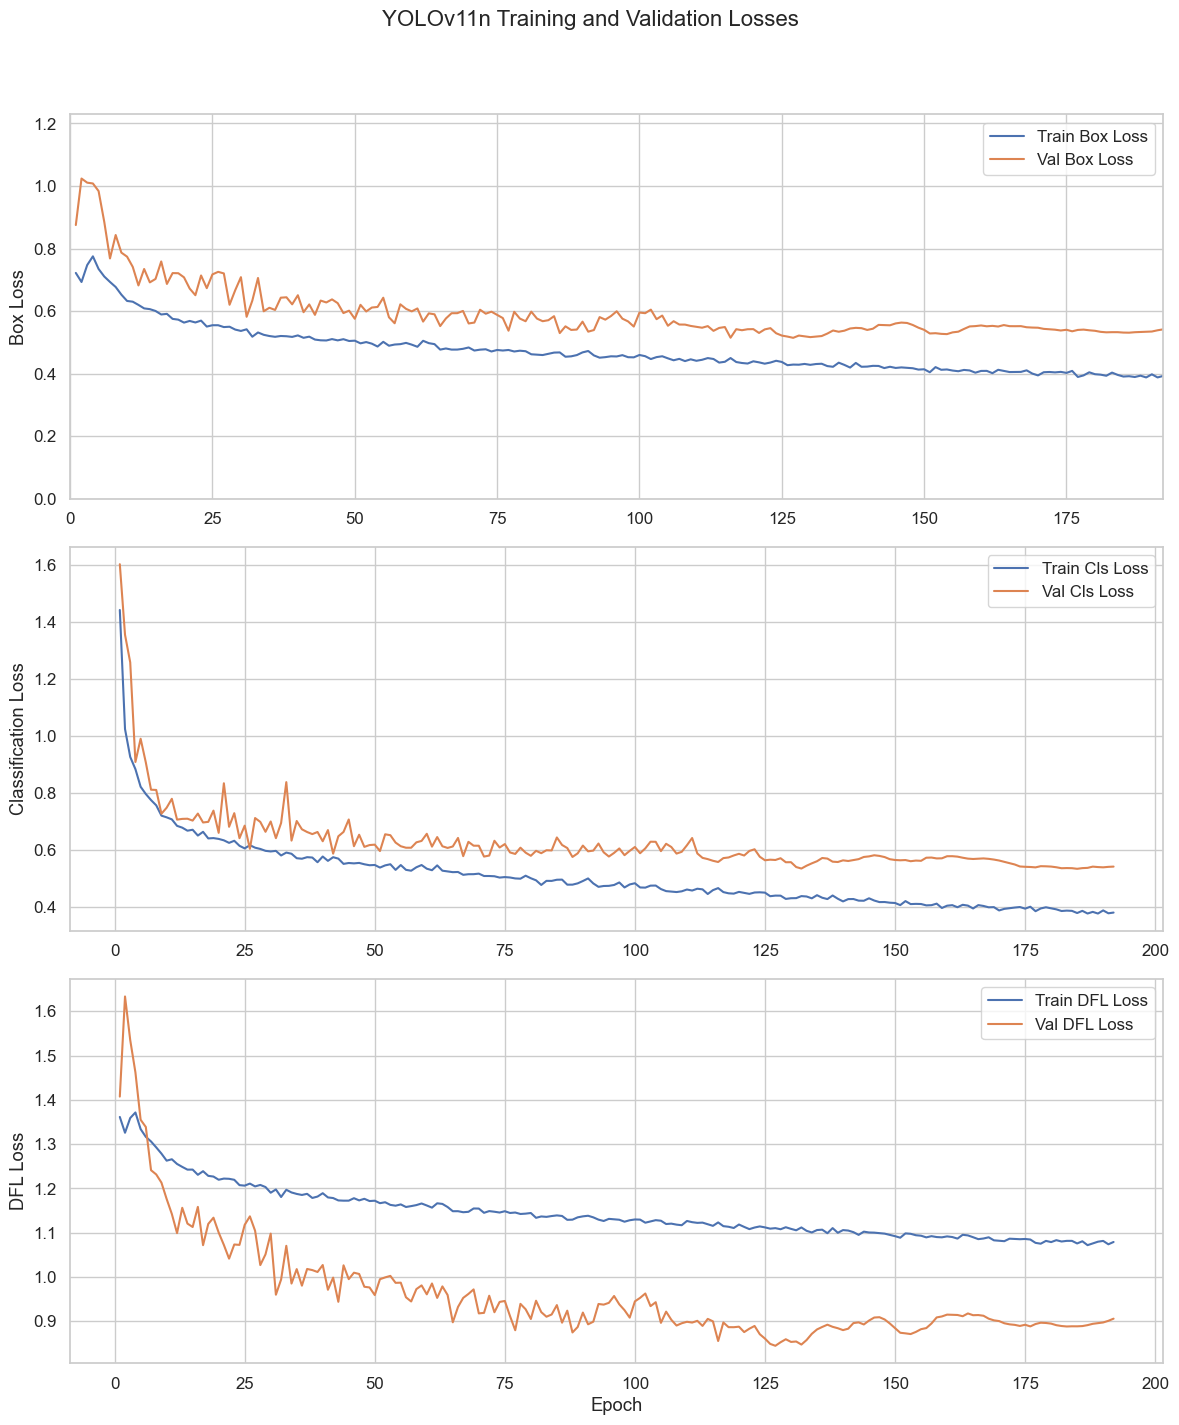

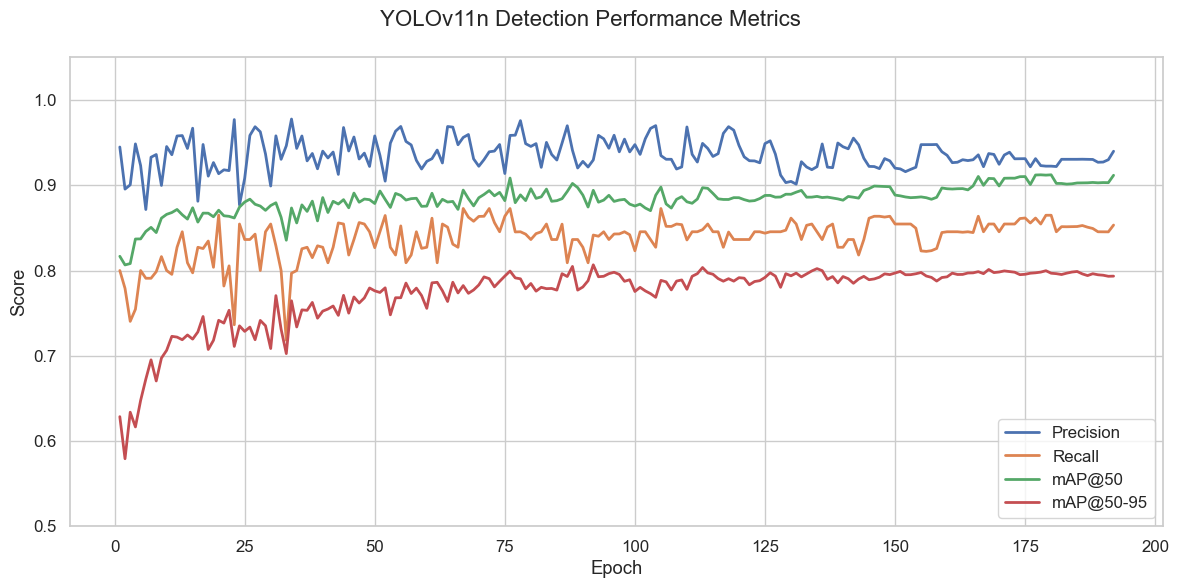

{'Epoch': 92,
 'Precision': 0.9297,
 'Recall': 0.84162,
 'mAP@50': 0.89413,
 'mAP@50-95': 0.80671,
 'Val Box Loss': 0.53946,
 'Val Cls Loss': 0.59874,
 'Val DFL Loss': 0.89876}

In [4]:

import pandas as pd

# Load the uploaded CSV file
file_path = 'MSV_results.csv'
df = pd.read_csv(file_path)

# Display basic info and first few rows to understand the structure
df.info(), df.head()


import matplotlib.pyplot as plt
import seaborn as sns

# Set Seaborn style
sns.set(style="whitegrid", palette="deep", font_scale=1.1)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 15))
fig.suptitle('YOLOv8n Training and Validation Losses', fontsize=16)

# Plot losses
axes[0].plot(df['epoch'], df['train/box_loss'], label='Train Box Loss')
axes[0].plot(df['epoch'], df['val/box_loss'], label='Val Box Loss')
axes[0].set_ylabel('Box Loss')
axes[0].legend()

# Dynamically extend y-axis scale
max_loss = max(df['train/box_loss'].max(), df['val/box_loss'].max())
axes[0].set_ylim(0, max_loss * 1.2)  # Extend 20% above the maximum loss

# Optionally adjust x-axis to match epochs
axes[0].set_xlim(0, df['epoch'].max())


axes[1].plot(df['epoch'], df['train/cls_loss'], label='Train Cls Loss')
axes[1].plot(df['epoch'], df['val/cls_loss'], label='Val Cls Loss')
axes[1].set_ylabel('Classification Loss')
axes[1].legend()

axes[2].plot(df['epoch'], df['train/dfl_loss'], label='Train DFL Loss')
axes[2].plot(df['epoch'], df['val/dfl_loss'], label='Val DFL Loss')
axes[2].set_ylabel('DFL Loss')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Plot Precision, Recall, and mAP over Epochs
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('YOLOv11n Detection Performance Metrics', fontsize=16)

ax.plot(df['epoch'], df['metrics/precision(B)'], label='Precision', linewidth=2)
ax.plot(df['epoch'], df['metrics/recall(B)'], label='Recall', linewidth=2)
ax.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50', linewidth=2)
ax.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95', linewidth=2)

ax.set_xlabel('Epoch')
ax.set_ylabel('Score')
ax.set_ylim(0.5, 1.05)
ax.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Find the best epoch based on highest mAP@50-95
best_epoch_idx = df['metrics/mAP50-95(B)'].idxmax()
best_epoch_data = df.loc[best_epoch_idx]

# Extract key values
best_epoch = int(best_epoch_data['epoch'])
best_metrics = {
    'Epoch': best_epoch,
    'Precision': best_epoch_data['metrics/precision(B)'],
    'Recall': best_epoch_data['metrics/recall(B)'],
    'mAP@50': best_epoch_data['metrics/mAP50(B)'],
    'mAP@50-95': best_epoch_data['metrics/mAP50-95(B)'],
    'Val Box Loss': best_epoch_data['val/box_loss'],
    'Val Cls Loss': best_epoch_data['val/cls_loss'],
    'Val DFL Loss': best_epoch_data['val/dfl_loss']
}

best_metrics


Confusion Matrix:
[[ 0  1]
 [ 2 98]]

Accuracy: 0.97

Classification Report:
              precision    recall  f1-score   support

 Healthy (0)       0.00      0.00      0.00         1
Infected (1)       0.99      0.98      0.98       100

    accuracy                           0.97       101
   macro avg       0.49      0.49      0.49       101
weighted avg       0.98      0.97      0.98       101



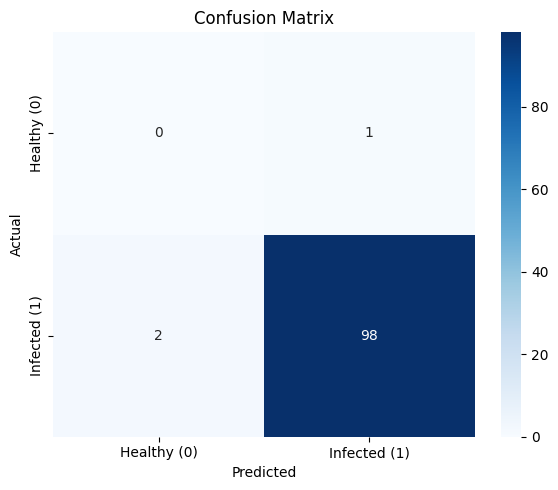

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# ---------------------
# Input values (update these as needed)
TP = 98  # True Positives (correctly detected MSV)
FN = 2    # False Negatives (missed MSV)
FP = 1    # False Positives (healthy misclassified as MSV)
TN = 0  # True Negatives (correctly identified healthy)
# ---------------------

# Create the actual (ground truth) and predicted labels
y_true = [1]*TP + [1]*FN + [0]*TN + [0]*FP
y_pred = [1]*TP + [0]*FN + [0]*TN + [1]*FP

# Compute Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
labels = ["Healthy (0)", "Infected (1)"]

# Print Confusion Matrix
print("Confusion Matrix:")
print(cm)

# Print Accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"\nAccuracy: {accuracy:.2f}")

# Print Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=labels))

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()